In [1]:
import time
from oggm import cfg, utils, workflow, tasks, graphics
from oggm.sandbox import ioggm_dynamic_spinup
from oggm.core.sia2d import IGM_Model2D # import the IGM_Model2D
from datetime import datetime
import os
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr


/Users/afisc/igm_venv/bin/python


#### load gdir of the glacier to calculate dmdtda and grab ref_dmdtda

In [2]:
cfg.initialize(logging_level='WARNING')
cfg.PATHS['working_dir'] = utils.gettempdir()
# rgi-id
rgi_ids = ['RGI60-11.01450']  # This is Aletsch
base_url = ('https://cluster.klima.uni-bremen.de/~oggm/gdirs/oggm_v1.6/'
            'L3-L5_files/2023.3/elev_bands/W5E5/')
gdirs = workflow.init_glacier_directories(rgi_ids,from_prepro_level=3, prepro_border=80, prepro_base_url=base_url)
gdir = gdirs[0]


2026-06-17 09:44:04: oggm.cfg: Reading default parameters from the OGGM `params.cfg` configuration file.
2026-06-17 09:44:04: oggm.cfg: Multiprocessing switched OFF according to the parameter file.
2026-06-17 09:44:04: oggm.cfg: Multiprocessing: using all available processors (N=8)
2026-06-17 09:44:04: oggm.workflow: init_glacier_directories from prepro level 3 on 1 glaciers.
2026-06-17 09:44:04: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 1 glaciers


In [3]:
comparison_name = 'iOGGM - OGGM spinup - AREA ref - GCM Ensemble 3 ssp'
diag_paths = {
              'iOGGM spinup_period':
                    '/Users/afisc/instructed-oggm/experiments_working_dir/06_11/iOGGM_spinup_and_gcm/20260611-123231__area/per_glacier/RGI60-11/RGI60-11.01/RGI60-11.01450/ioggm_diagnostics_spinup_area_spinup.nc',
              'iOGGM post_spinup':
                    '/Users/afisc/instructed-oggm/experiments_working_dir/06_11/iOGGM_spinup_and_gcm/20260611-123231__area/per_glacier/RGI60-11/RGI60-11.01/RGI60-11.01450/ioggm_diagnostics_spinup_area.nc',
              **{
              f'iOGGM quantiles {ssp}':
              f'/Users/afisc/instructed-oggm/experiments_working_dir/06_11/iOGGM_spinup_and_gcm/20260611-123231__area/per_glacier/RGI60-11/RGI60-11.01/RGI60-11.01450/ioggm_diagnostics_{ssp}_quantiles.nc'
                for ssp in ['ssp126', 'ssp245', 'ssp585']
                },
    
              'OGGM spinup_period':
                    '/Users/afisc/instructed-oggm/experiments_working_dir/06_11/OGGM_spinup_and_gcm/20260611-123524__area/per_glacier/RGI60-11/RGI60-11.01/RGI60-11.01450/model_diagnostics_spinup_area_spinup.nc',
              'OGGM post_spinup':
                    '/Users/afisc/instructed-oggm/experiments_working_dir/06_11/OGGM_spinup_and_gcm/20260611-123524__area/per_glacier/RGI60-11/RGI60-11.01/RGI60-11.01450/model_diagnostics_spinup_area.nc',
              **{
              f'OGGM quantiles {ssp}':
              f'/Users/afisc/instructed-oggm/experiments_working_dir/06_11/OGGM_spinup_and_gcm/20260611-123524__area/per_glacier/RGI60-11/RGI60-11.01/RGI60-11.01450/model_diagnostics_{ssp}_quantiles.nc'
              for ssp in ['ssp126', 'ssp245', 'ssp585']
              }
              }

In [4]:
plot_colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

In [5]:
cfg.initialize(logging_level='WARNING')

ts = datetime.now().strftime("%Y%m%d-%H%M%S")
cfg.PATHS['working_dir'] = os.path.join('/Users/afisc/instructed-oggm/experiments_working_dir/first_spinup_comparison/{}_{}'.format(ts, comparison_name))


2026-06-17 09:44:05: oggm.cfg: Reading default parameters from the OGGM `params.cfg` configuration file.
2026-06-17 09:44:05: oggm.cfg: Multiprocessing switched OFF according to the parameter file.
2026-06-17 09:44:05: oggm.cfg: Multiprocessing: using all available processors (N=8)


## Identify diagnostic files of each spinup run

In [6]:
def preprocess_OGGM_run(path):
    with xr.open_dataset(path) as ds:
        ds = ds.load()  # ensure data is in memory before overwriting
    ds = ds.copy()
    # Add converted variables
    ds["volume_km3"] = ds["volume_m3"] / 1e9
    ds["area_km2"] = ds["area_m2"] / 1e6

    tmp = path + ".tmp"
    ds.to_netcdf(tmp)
    os.replace(tmp, path)

In [7]:
import os
import xarray as xr


def convert_diagnostics(ncfile):
    """
    sum all variables over the coordinate 'dis_along_flowline',
    save the reduced dataset to a new file,
    and return the new file path.

    Parameters
    ----------
    ncfile : str
        Path to input NetCDF file.

    Returns
    -------
    str
        Path to converted NetCDF file.
    """

    # Open dataset
    ds = xr.open_dataset(ncfile, group='fl_0')

    # Sum all variables that contain the dimension
    vars_new = {}

    for name, da in ds.data_vars.items():

        if "dis_along_flowline" in da.dims:
            vars_new[name] = da.sum(dim="dis_along_flowline")
        else:
            vars_new[name] = da

    # Create reduced dataset
    ds_new = xr.Dataset(vars_new, attrs=ds.attrs)

    # Output filename
    base, ext = os.path.splitext(ncfile)
    outfile = f"{base}_summed_along_fl{ext}"

    # Save
    ds_new.to_netcdf(outfile)

    return outfile

In [8]:
# diag_paths['OGGM GCM ensemble mean_summed'] = convert_diagnostics(diag_paths['OGGM GCM ensemble mean'])
# diag_paths['OGGM GCM 025quantile_summed'] = convert_diagnostics(diag_paths['OGGM GCM 025quantile'])
# diag_paths['OGGM GCM 075quantile_summed'] = convert_diagnostics(diag_paths['OGGM GCM 075quantile'])
preprocess_OGGM_run(diag_paths['OGGM quantiles ssp126'])
preprocess_OGGM_run(diag_paths['OGGM quantiles ssp245'])
preprocess_OGGM_run(diag_paths['OGGM quantiles ssp585'])
preprocess_OGGM_run(diag_paths['OGGM post_spinup'])
preprocess_OGGM_run(diag_paths['OGGM spinup_period'])

In [9]:
def get_time_area_volume(path, quantiles=False):
    if quantiles:
        with xr.open_dataset(path) as ds:
            time = ds['time']
            area = ds['area_km2'].sel(quantile=0.5)
            volume = ds['volume_km3'].sel(quantile=0.5)
            area_q25 = ds['area_km2'].sel(quantile=0.25)
            volume_q25 = ds['volume_km3'].sel(quantile=0.25)
            area_q75 = ds['area_km2'].sel(quantile=0.75)
            volume_q75 = ds['volume_km3'].sel(quantile=0.75)
            
        
        return time, area, volume, area_q25, volume_q25, area_q75, volume_q75
    else:
        with xr.open_dataset(path) as ds:
            time = ds['time']
            area = ds['area_km2']
            volume = ds['volume_km3']
        return time, area, volume
    
def adapt_spinup_time(spinup_time, post_spinup_time):
    """
    Adapt spinup_time so that:
    - it keeps the original length
    - it keeps the original timestep spacing
    - its final value is exactly one timestep before
      the first value of post_spinup_time
    """

    spinup_vals = np.asarray(spinup_time)

    # infer timestep from original spinup_time
    if len(spinup_vals) > 1:
        step = spinup_vals[1] - spinup_vals[0]
    else:
        step = 1

    n = len(spinup_vals)

    first_post_year = post_spinup_time.values[0]

    end_year = first_post_year
    start_year = end_year - step * (n - 1)

    new_vals = np.arange(start_year, end_year + step, step)

    return xr.DataArray(
        new_vals,
        dims=spinup_time.dims,
        coords=spinup_time.coords,
    )

## let the plotting begin

In [10]:

# get data
ioggm_spinup_time, ioggm_spinup_area, ioggm_spinup_volume = get_time_area_volume(diag_paths['iOGGM spinup_period'])
ioggm_post_spinup_time, ioggm_post_spinup_area, ioggm_post_spinup_volume = get_time_area_volume(diag_paths['iOGGM post_spinup'])
ioggm_gcm_time_1, ioggm_gcm_area_1, ioggm_gcm_volume_1, ioggm_gcm_025_area_1, ioggm_gcm_025_volume_1, ioggm_gcm_075_area_1, ioggm_gcm_075_volume_1 = get_time_area_volume(diag_paths['iOGGM quantiles ssp126'], quantiles=True)
ioggm_gcm_time_2, ioggm_gcm_area_2, ioggm_gcm_volume_2, ioggm_gcm_025_area_2, ioggm_gcm_025_volume_2, ioggm_gcm_075_area_2, ioggm_gcm_075_volume_2 = get_time_area_volume(diag_paths['iOGGM quantiles ssp245'], quantiles=True)
ioggm_gcm_time_3, ioggm_gcm_area_3, ioggm_gcm_volume_3, ioggm_gcm_025_area_3, ioggm_gcm_025_volume_3, ioggm_gcm_075_area_3, ioggm_gcm_075_volume_3 = get_time_area_volume(diag_paths['iOGGM quantiles ssp585'], quantiles=True)


oggm_spinup_time, oggm_spinup_area, oggm_spinup_volume = get_time_area_volume(diag_paths['OGGM spinup_period'])
oggm_post_spinup_time, oggm_post_spinup_area, oggm_post_spinup_volume = get_time_area_volume(diag_paths['OGGM post_spinup'])
oggm_gcm_time_1, oggm_gcm_area_1, oggm_gcm_volume_1, oggm_gcm_025_area_1, oggm_gcm_025_volume_1, oggm_gcm_075_area_1, oggm_gcm_075_volume_1 = get_time_area_volume(diag_paths['OGGM quantiles ssp126'], quantiles=True)
oggm_gcm_time_2, oggm_gcm_area_2, oggm_gcm_volume_2, oggm_gcm_025_area_2, oggm_gcm_025_volume_2, oggm_gcm_075_area_2, oggm_gcm_075_volume_2 = get_time_area_volume(diag_paths['OGGM quantiles ssp245'], quantiles=True)
oggm_gcm_time_3, oggm_gcm_area_3, oggm_gcm_volume_3, oggm_gcm_025_area_3, oggm_gcm_025_volume_3, oggm_gcm_075_area_3, oggm_gcm_075_volume_3 = get_time_area_volume(diag_paths['OGGM quantiles ssp585'], quantiles=True)




In [11]:
ioggm_spinup_time = adapt_spinup_time(ioggm_spinup_time, ioggm_post_spinup_time)
oggm_spinup_time = adapt_spinup_time(oggm_spinup_time, oggm_post_spinup_time)

### calculate dmdtda 

In [12]:
dmdtda_ioggm = ((ioggm_post_spinup_volume.sel(time=2020).item() * 1e9 - ioggm_post_spinup_volume.sel(time=2000).item() * 1e9) /
                gdir.rgi_area_m2 / (2020-2000) * cfg.PARAMS['ice_density'])

dmdtda_oggm = ((oggm_post_spinup_volume.sel(time=2020).item() * 1e9 - oggm_post_spinup_volume.sel(time=2000).item() * 1e9) /
                gdir.rgi_area_m2 / (2020-2000) * cfg.PARAMS['ice_density'])



In [13]:
ref_period = cfg.PARAMS['geodetic_mb_period']
df_ref_dmdtda = utils.get_geodetic_mb_dataframe().loc[gdir.rgi_id]
sel = df_ref_dmdtda.loc[df_ref_dmdtda['period'] == ref_period].iloc[0]
# reference geodetic mass balance from Hugonnet 2021
ref_dmdtda = float(sel['dmdtda'])
# dmdtda: in meters water-equivalent per year -> we convert
ref_dmdtda *= 1000  # kg m-2 yr-1
# error of reference geodetic mass balance from Hugonnet 2021
err_ref_dmdtda = float(sel['err_dmdtda'])
err_ref_dmdtda *= 1000  # kg m-2 yr-1

In [14]:
dmdtda_oggm

-1327.513329247472

In [15]:
-1210.7 + 126.096


-1084.604

## plot colors

In [16]:
# plot colors:
# for area plots:
# iOGGM
teal = ["#01665e", "#5ab4ac", "#8dd3c7"]
# OGGM
purple = ["#542788", "#998ec3", "#b2abd2"]

# for volume plots:
# for iOGGM
navy   = ["#253494", "#2c7fb8", "#a6bddb"]
# for OGGM
brown  = ["#8c510a", "#bf812d", "#dfc27d"]


In [17]:
## new color palette:

# ======================
# AREA
# ======================

# Area 1
teal = ["#01665e", "#5ab4ac", "#8dd3c7"]      # iOGGM
purple = ["#542788", "#998ec3", "#b2abd2"]    # OGGM

# Area 2
forest = ["#006d2c", "#31a354", "#74c476"]    # iOGGM
magenta = ["#7a0177", "#c51b8a", "#f1b6da"]   # OGGM

# Area 3
cyan = ["#0868ac", "#43a2ca", "#a8ddb5"]      # iOGGM
red = ["#b2182b", "#d6604d", "#f4a582"]       # OGGM


# ======================
# VOLUME
# ======================

# Volume 1
navy = ["#253494", "#2c7fb8", "#a6bddb"]      # iOGGM
brown = ["#8c510a", "#bf812d", "#dfc27d"]     # OGGM

# Volume 2
indigo = ["#3f007d", "#6a51a3", "#bcbddc"]    # iOGGM
orange = ["#d94801", "#f16913", "#fdae6b"]    # OGGM

# Volume 3
steel = ["#084594", "#2171b5", "#9ecae1"]     # iOGGM
gold = ["#b35806", "#e08214", "#fdd49e"]      # OGGM

## plot area:

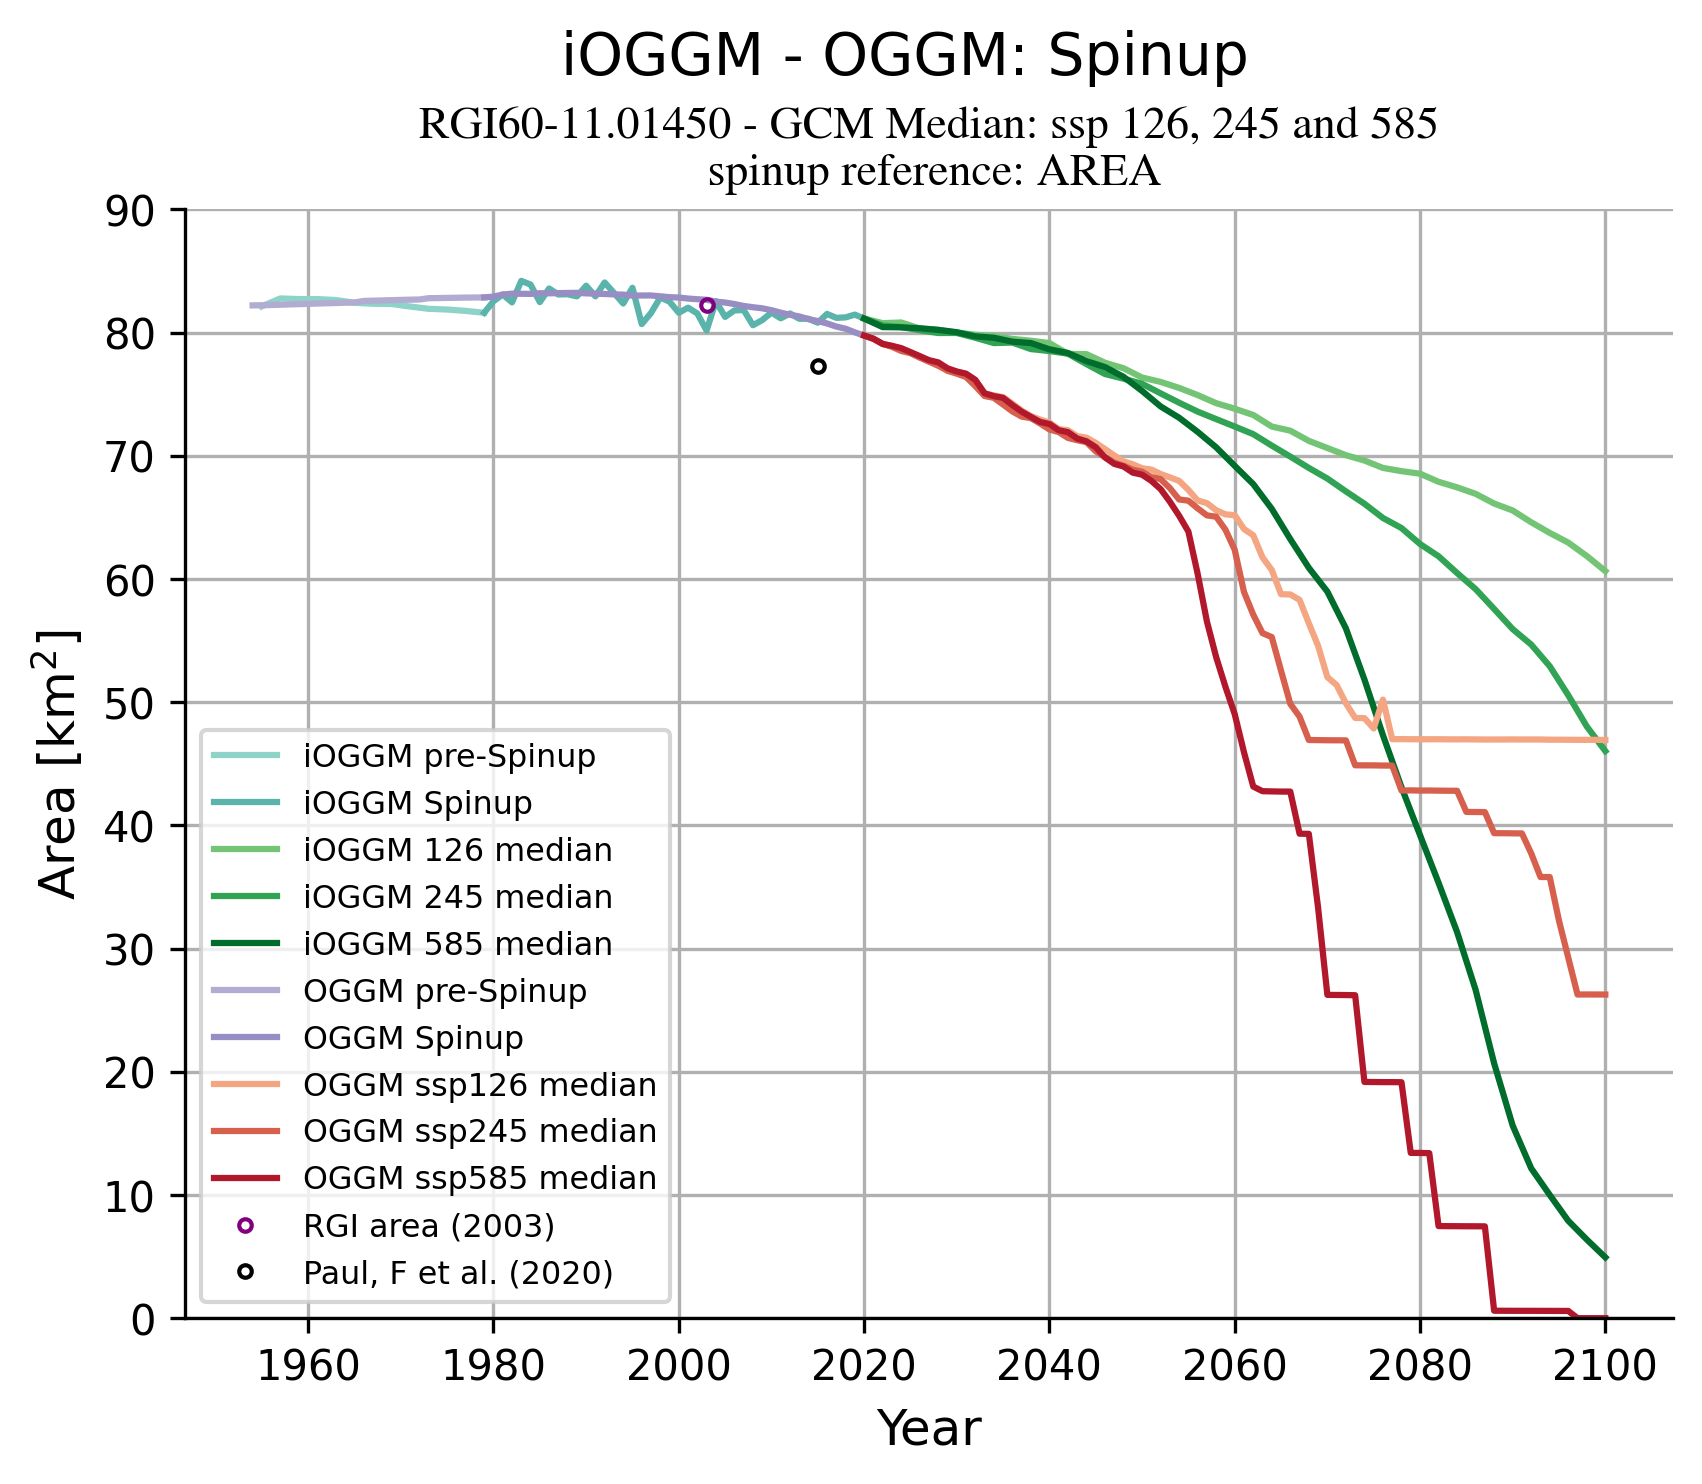

In [18]:
# paper-like style
plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
fig, ax = plt.subplots()


# plot iOGGM 


ioggm_spinup_plot = ax.plot(
    ioggm_spinup_time,
    ioggm_spinup_area,
    color=teal[2],
    label='iOGGM pre-Spinup'
)
ioggm_post_spinup_plot = ax.plot(
    ioggm_post_spinup_time,
    ioggm_post_spinup_area,
    color=teal[1],
    label='iOGGM Spinup'
    # color= ioggm_spinup_plot.get_color()
)

ioggm_126_plot = ax.plot(
    ioggm_gcm_time_1,
    ioggm_gcm_area_1,
    color=forest[2],
    label='iOGGM 126 median'
)

ioggm_245_plot = ax.plot(
    ioggm_gcm_time_2,
    ioggm_gcm_area_2,
    color=forest[1],
    label='iOGGM 245 median'
)

ioggm_585_plot = ax.plot(
    ioggm_gcm_time_3,
    ioggm_gcm_area_3,
    color=forest[0],
    label='iOGGM 585 median'
)

# ax.fill_between(
#     ioggm_gcm_time,
#     ioggm_gcm_025_area,
#     ioggm_gcm_075_area,
#     color=teal[0],
#     alpha=0.25,   # transparency
# )

# plot OGGM 
oggm_plot_color = None

oggm_spinup_plot = ax.plot(
    oggm_spinup_time,
    oggm_spinup_area,
    color=purple[2],
    label='OGGM pre-Spinup'
)
oggm_post_spinup_plot = ax.plot(
    oggm_post_spinup_time,
    oggm_post_spinup_area,
    color=purple[1],
    label='OGGM Spinup'
    # color= ioggm_spinup_plot.get_color()
)

oggm_126_plot = ax.plot(
    oggm_gcm_time_1,
    oggm_gcm_area_1,
    color=red[2],
    label='OGGM ssp126 median'
)

oggm_245_plot = ax.plot(
    oggm_gcm_time_2,
    oggm_gcm_area_2,
    color=red[1],
    label='OGGM ssp245 median'
)

oggm_585_plot = ax.plot(
    oggm_gcm_time_3,
    oggm_gcm_area_3,
    color=red[0],
    label='OGGM ssp585 median'
)



# ax.fill_between(
#     oggm_gcm_time,
#     oggm_gcm_025_area,
#     oggm_gcm_075_area,
#     color=purple[0],
#     alpha=0.25,   # transparency
# )

# optional values to plot: 
ax.plot(2003, 82.206, 'o', markersize=3, color='purple', markerfacecolor='none', label='RGI area (2003)')
ax.plot(2015, 77.25, 'o', markersize=3, color='black',markerfacecolor='none', label='Paul, F et al. (2020)')
# 


ax.legend(fontsize='x-small')

ax.set_ylim(0,90)

# figure title
fig.suptitle('iOGGM - OGGM: Spinup', y=1.005, fontsize=14)
# other title
ax.set_title(f'{gdir.rgi_id} - GCM Median: ssp 126, 245 and 585\n spinup reference: AREA', font='STIXGeneral')
ax.grid()
ax.set_xlabel('Year')
ax.set_ylabel(r'Area [km$^2$]')
fig.savefig("AREA_PLOT.png", dpi=300, bbox_inches="tight")
plt.show()

## plot volume:

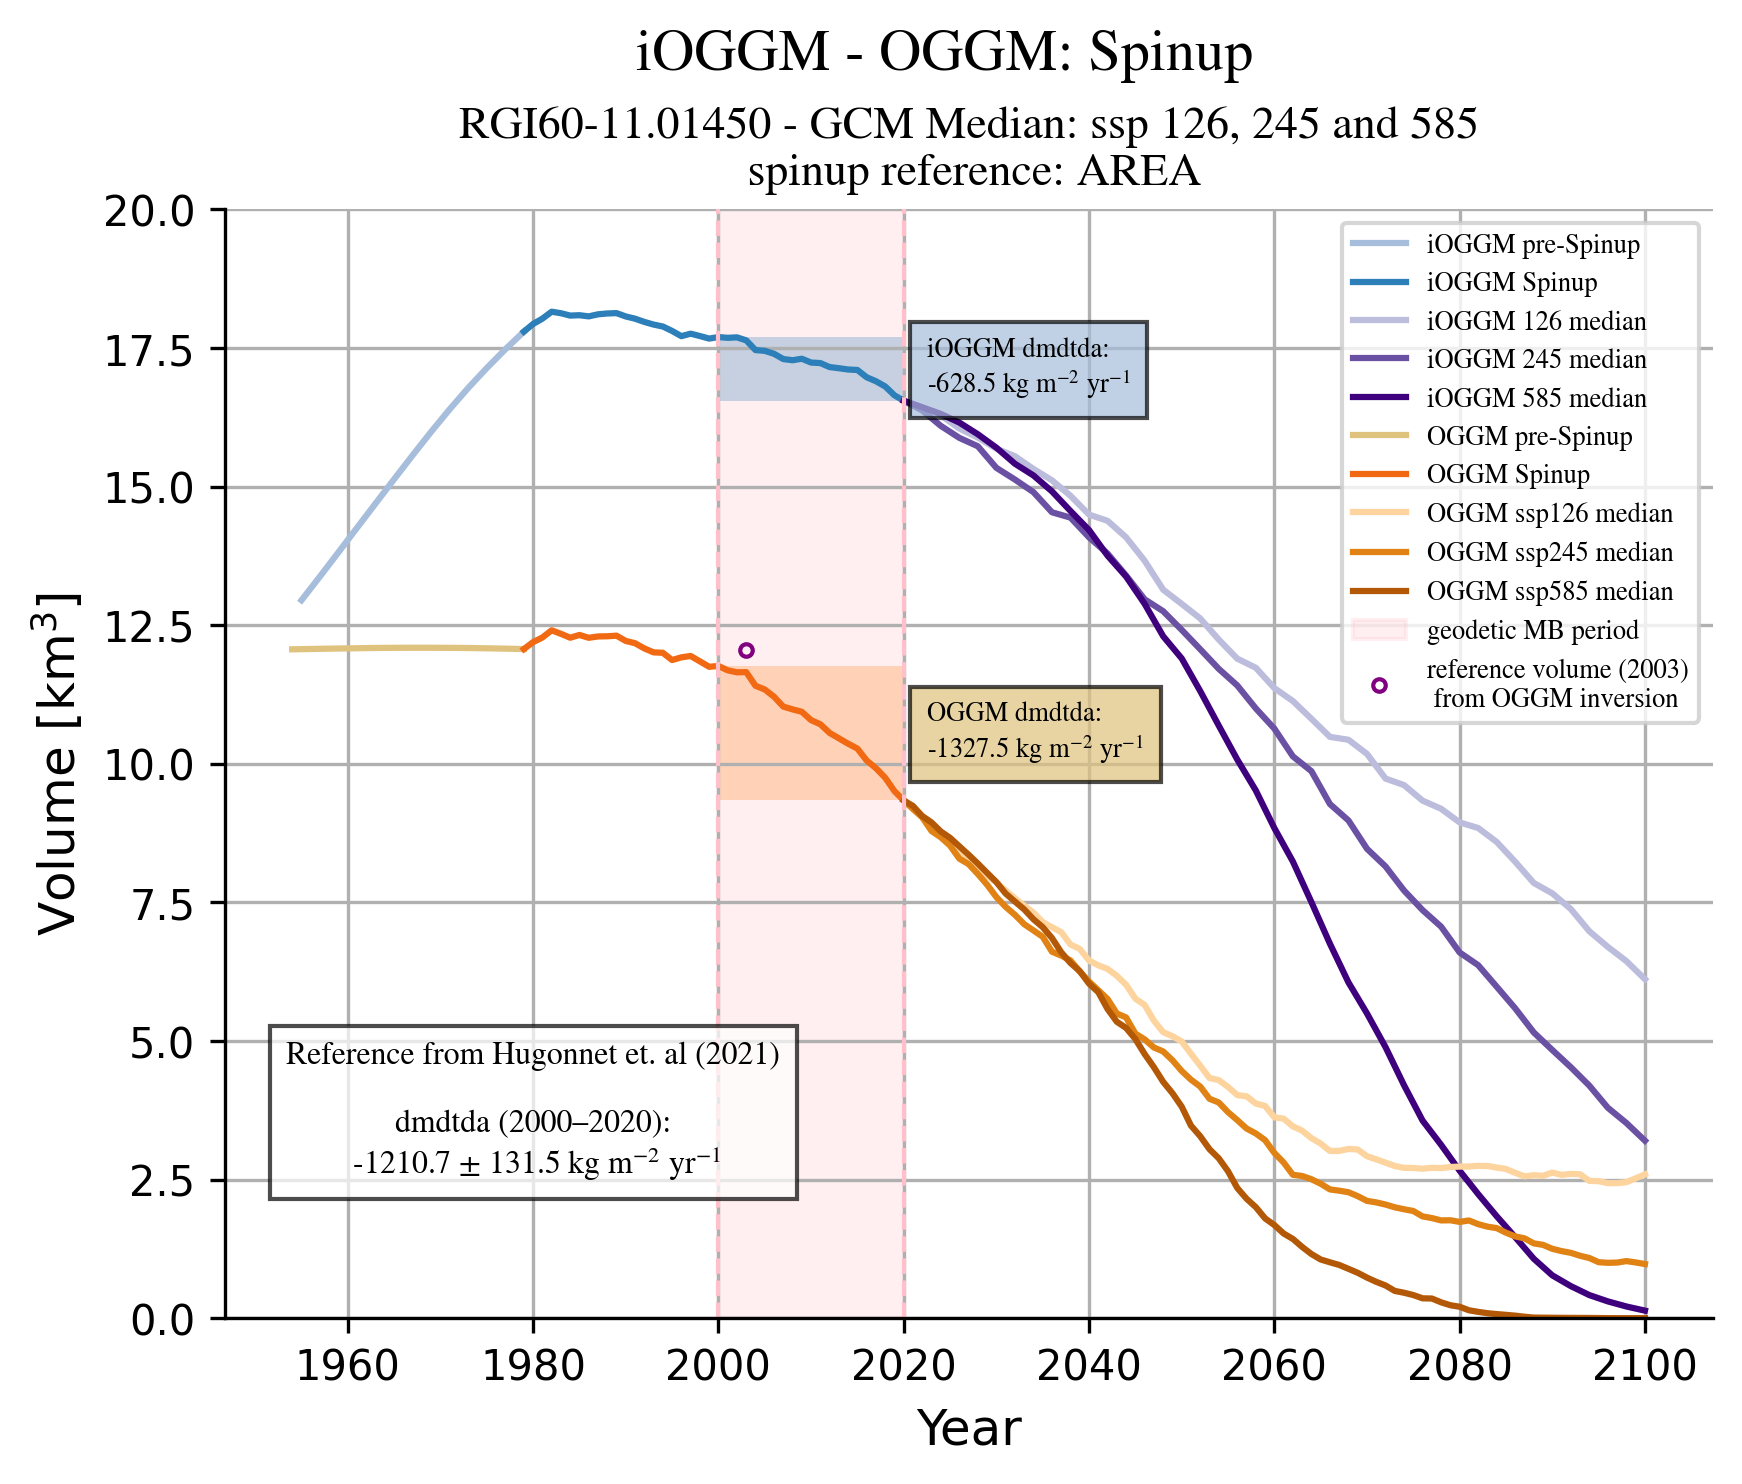

In [19]:
fig, ax = plt.subplots()


import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['mathtext.fontset'] = 'stix'
# paper-like style
plt.rcParams.update({
    "font.size": 11,
    'font.family': 'STIXGeneral',
    'mathtext.fontset': 'stix',
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
    
    "lines.linewidth": 1.5,
})

# plot iOGGM 

ioggm_spinup_plot = ax.plot(
    ioggm_spinup_time,
    ioggm_spinup_volume,
    color=navy[2],
    label='iOGGM pre-Spinup'
)
ioggm_post_spinup_plot = ax.plot(
    ioggm_post_spinup_time,
    ioggm_post_spinup_volume,
    color=navy[1],
    label='iOGGM Spinup'
    # color= ioggm_spinup_plot.get_color()
)

ioggm_126_plot = ax.plot(
    ioggm_gcm_time_1,
    ioggm_gcm_volume_1,
    color=indigo[2],
    label='iOGGM 126 median'
)

ioggm_245_plot = ax.plot(
    ioggm_gcm_time_2,
    ioggm_gcm_volume_2,
    color=indigo[1],
    label='iOGGM 245 median'
)

ioggm_585_plot = ax.plot(
    ioggm_gcm_time_3,
    ioggm_gcm_volume_3,
    color=indigo[0],
    label='iOGGM 585 median'
)


# ax.fill_between(
#     ioggm_gcm_time,
#     ioggm_gcm_025_volume,
#     ioggm_gcm_075_volume,
#     color=navy[0],
#     alpha=0.25,   # transparency
# )

# plot OGGM 

oggm_spinup_plot = ax.plot(
    oggm_spinup_time,
    oggm_spinup_volume,
    color=brown[2],
    label='OGGM pre-Spinup'
)
oggm_post_spinup_plot = ax.plot(
    oggm_post_spinup_time,
    oggm_post_spinup_volume,
    color=orange[1],
    label='OGGM Spinup'
    # color= ioggm_spinup_plot.get_color()
)

oggm_126_plot = ax.plot(
    oggm_gcm_time_1,
    oggm_gcm_volume_1,
    color=gold[2],
    label='OGGM ssp126 median'
)

oggm_245_plot = ax.plot(
    oggm_gcm_time_2,
    oggm_gcm_volume_2,
    color=gold[1],
    label='OGGM ssp245 median'
)

oggm_585_plot = ax.plot(
    oggm_gcm_time_3,
    oggm_gcm_volume_3,
    color=gold[0],
    label='OGGM ssp585 median'
)

# ax.fill_between(
#     oggm_gcm_time,
#     oggm_gcm_025_volume,
#     oggm_gcm_075_volume,
#     color=brown[0],
#     alpha=0.25,   # transparency
# )

for year in [2000, 2020]:
    ax.axvline(year, linestyle='--', linewidth=1, color='pink')
    
ax.axvspan(2000, 2020, alpha=0.25, label='geodetic MB period', color='pink')

# highlight delta(V) between 2000 and 2020
t1 = ioggm_post_spinup_volume.sel(time=slice(2000, 2020))
t2 = oggm_post_spinup_volume.sel(time=slice(2000, 2020))
# values
v1_2000 = ioggm_post_spinup_volume.sel(time=2000).item()
v1_2020 = ioggm_post_spinup_volume.sel(time=2020).item()

v2_2000 = oggm_post_spinup_volume.sel(time=2000).item()
v2_2020 = oggm_post_spinup_volume.sel(time=2020).item()

ax.fill_between(t1["time"], v1_2000, v1_2020, alpha=0.25)
ax.fill_between(t2["time"], v2_2000, v2_2020, alpha=0.25)



ax.text(
    2020 + 2.5,
    (v1_2000 + v1_2020)/2,
    'iOGGM dmdtda:\n' + f'{dmdtda_ioggm:.1f} ' + r'kg m$^{-2}$ yr$^{-1}$',
    va="center",
    fontsize='xx-small', 
    bbox=dict(
        facecolor=navy[2],
        edgecolor="black",
        alpha=0.7
    ), )

ax.text(
    2020 + 2.5,
    (v2_2000 + v2_2020)/2,
    'OGGM dmdtda:\n' + f'{dmdtda_oggm:.1f} ' + r'kg m$^{-2}$ yr$^{-1}$',
    va="center",
    fontsize='xx-small', 
    bbox=dict(
        facecolor=brown[2],
        edgecolor="black",
        alpha=0.7
    ), )

ax.text(
    1980, 5,
    f"Reference from Hugonnet et. al (2021)\n\ndmdtda (2000–2020):\n {ref_dmdtda} ± {err_ref_dmdtda} "+ r'kg m$^{-2}$ yr$^{-1}$',
    ha="center",
    va="top",
    bbox=dict(
        facecolor="white",
        edgecolor="black",
        alpha=0.7
    ),
    fontsize='x-small'
)


ax.plot(2003, 12.06, 'o', markersize=3, color='purple', markerfacecolor='none', label='reference volume (2003)\n from OGGM inversion')


ax.legend(fontsize='xx-small')
ax.grid()
ax.set_xlabel('Year')
ax.set_ylabel(r'Volume [km$^3$]')
ax.set_ylim(0,20)
# main title
fig.suptitle('iOGGM - OGGM: Spinup', y=1.005, fontsize=14)
# other title
ax.set_title(f'{gdir.rgi_id} - GCM Median: ssp 126, 245 and 585\n spinup reference: AREA', font='STIXGeneral')
fig.savefig("VOLUME_PLOT.png", dpi=300, bbox_inches="tight")
plt.show()